# EXPERIMENT NO: 7 — Clustering using K-Means and Gaussian Mixture Models (GMM)
**Date: 08.04.2026**  
**Roll No: 24BAD002**  

---

## SCENARIO 1 — CLUSTERING USING K-MEANS

---

### Step 1: Import Required Libraries

In [ ]:
# Step 1: Import required Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load the Dataset

In [ ]:
# Step 2: Load the Mall Customers dataset
df = pd.read_csv('Mall_Customers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (200, 5)

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Column Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


### Step 3: Data Preprocessing

In [ ]:
# Step 3: Data Preprocessing

# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

Missing Values per Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


### Step 4: Feature Selection and Scaling

In [ ]:
# Step 4: Select relevant features and apply StandardScaler
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Selected Features: Annual Income (k$), Spending Score (1-100)")
print("Original Data (first 5 rows):")
print(X[:5])
print("\nScaled Data (first 5 rows):")
print(X_scaled[:5].round(4))

Selected Features: Annual Income (k$), Spending Score (1-100)
Original Data (first 5 rows):
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]

Scaled Data (first 5 rows):
[[-1.739  -0.4348]
 [-1.739   1.1957]
 [-1.7008 -1.7159]
 [-1.7008  1.0404]
 [-1.6627 -0.396 ]]


### Step 5: Elbow Method to Determine Optimal K

In [ ]:
# Step 5: Elbow Method — compute inertia for K = 1 to 10
inertias = []
silhouette_scores = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        labels = km.labels_
        sil = silhouette_score(X_scaled, labels)
        silhouette_scores.append(sil)
    else:
        silhouette_scores.append(None)

print(f"{'K':>4} {'Inertia':>14} {'Silhouette':>14}")
print("-" * 35)
for k, iner, sil in zip(K_range, inertias, silhouette_scores):
    sil_str = f"{sil:.4f}" if sil is not None else "  N/A  "
    print(f"{k:>4} {iner:>14.4f} {sil_str:>14}")

   K        Inertia     Silhouette
-----------------------------------
   1       400.0000          N/A  
   2       269.6910         0.3213
   3       157.7040         0.4666
   4       108.9213         0.4939
   5        65.5684         0.5547
   6        55.0573         0.5399
   7        44.8648         0.5281
   8        37.2282         0.4552
   9        32.3923         0.4571
  10        29.9819         0.4432


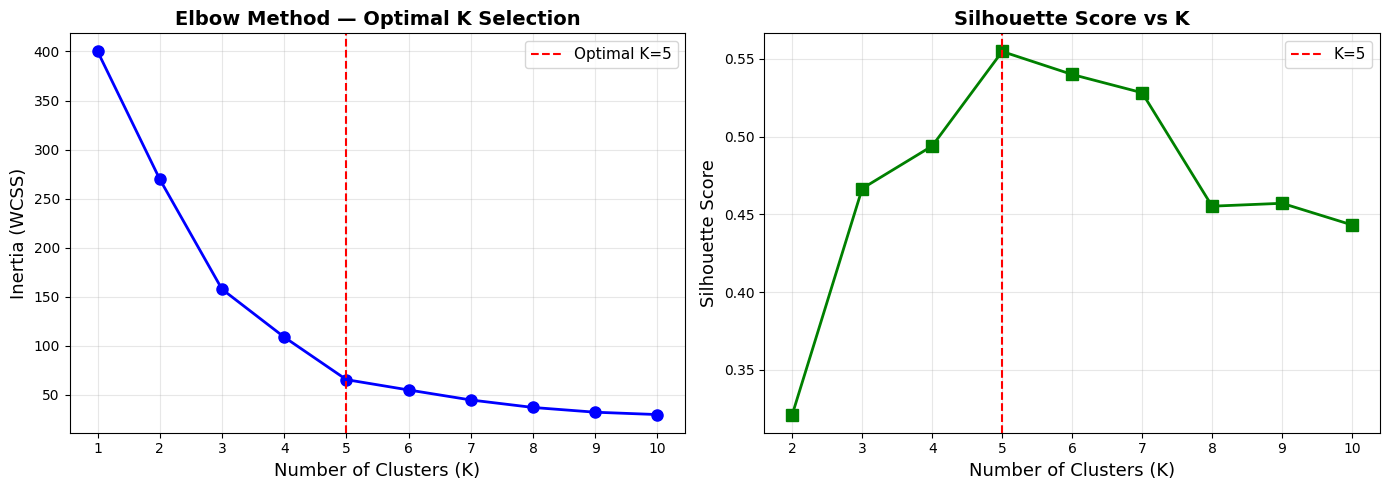

Optimal K = 5 (elbow point with significant drop in inertia)


In [ ]:
# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=13)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=13)
axes[0].set_title('Elbow Method — Optimal K Selection', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(K_range))

# Silhouette scores
sil_vals = [s for s in silhouette_scores if s is not None]
k_vals   = list(range(2, 11))
axes[1].plot(k_vals, sil_vals, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', label='K=5')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=13)
axes[1].set_ylabel('Silhouette Score', fontsize=13)
axes[1].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_vals)

plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Optimal K = 5 (elbow point with significant drop in inertia)")

### Step 6 & 7: Apply K-Means and Assign Cluster Labels

In [ ]:
# Step 6 & 7: Apply K-Means with K=5 and assign labels
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df['KMeans_Cluster'] = kmeans.labels_
cluster_labels_km = kmeans.labels_

# Evaluation metrics
inertia_final = kmeans.inertia_
sil_score_km  = silhouette_score(X_scaled, cluster_labels_km)

print(f"K-Means Clustering Results (K = {optimal_k})")
print("=" * 45)
print(f"  Inertia (WCSS)    : {inertia_final:.4f}")
print(f"  Silhouette Score  : {sil_score_km:.4f}")
print()
print("Cluster Distribution:")
for c in range(optimal_k):
    count = np.sum(cluster_labels_km == c)
    print(f"  Cluster {c}: {count} customers")

K-Means Clustering Results (K = 5)
  Inertia (WCSS)    : 65.5684
  Silhouette Score  : 0.5547

Cluster Distribution:
  Cluster 0: 81 customers
  Cluster 1: 39 customers
  Cluster 2: 22 customers
  Cluster 3: 35 customers
  Cluster 4: 23 customers


### Step 8: Visualize Clusters

Cluster Centroids (Original Scale):
 Annual Income (k$)  Spending Score (1-100)  Cluster
          55.296296               49.518519        0
          86.538462               82.128205        1
          25.727273               79.363636        2
          88.200000               17.114286        3
          26.304348               20.913043        4


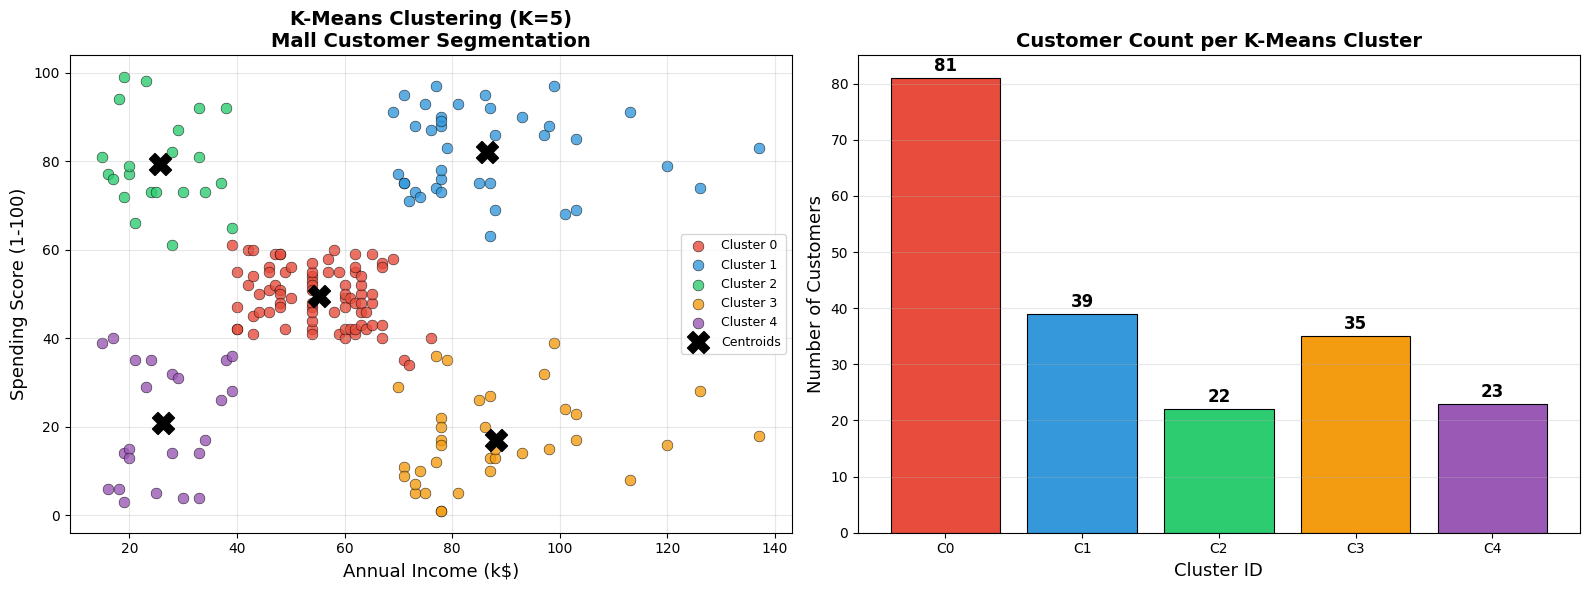

In [ ]:
# Step 8: Visualize K-Means clusters with centroids
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
cluster_names = [
    'Average Income / Average Spending',
    'Low Income / High Spending',
    'High Income / High Spending',
    'High Income / Low Spending',
    'Low Income / Low Spending'
]

# Re-map cluster IDs to descriptive names based on centroid analysis
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_original,
                           columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centroid_df['Cluster'] = range(optimal_k)

print("Cluster Centroids (Original Scale):")
print(centroid_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
for c in range(optimal_k):
    mask = cluster_labels_km == c
    axes[0].scatter(X[mask, 0], X[mask, 1],
                    c=colors[c], label=f'Cluster {c}',
                    s=60, alpha=0.8, edgecolors='k', linewidths=0.4)

# Plot centroids in original scale
axes[0].scatter(centroids_original[:, 0], centroids_original[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)', fontsize=13)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=13)
axes[0].set_title('K-Means Clustering (K=5)\nMall Customer Segmentation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bar chart of cluster sizes
cluster_counts = [np.sum(cluster_labels_km == c) for c in range(optimal_k)]
bars = axes[1].bar([f'C{c}' for c in range(optimal_k)], cluster_counts,
                   color=colors, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, cluster_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster ID', fontsize=13)
axes[1].set_ylabel('Number of Customers', fontsize=13)
axes[1].set_title('Customer Count per K-Means Cluster', fontsize=14, fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 9: Interpret Cluster Characteristics

In [ ]:
# Step 9: Analyze cluster characteristics
print("K-Means Cluster Profile (Mean Values — Original Scale)")
print("=" * 60)
cluster_summary = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_summary['Count'] = df.groupby('KMeans_Cluster').size()
print(cluster_summary)

print("\nCluster Interpretation:")
print("-" * 60)
for c in range(optimal_k):
    row = cluster_summary.loc[c]
    income  = row['Annual Income (k$)']
    spend   = row['Spending Score (1-100)']
    age     = row['Age']
    cnt     = int(row['Count'])
    inc_lbl = 'High' if income > 60 else 'Low'
    spc_lbl = 'High' if spend  > 50 else 'Low'
    print(f"  Cluster {c}: {inc_lbl} Income / {spc_lbl} Spending "
          f"| Avg Age={age:.1f} | N={cnt}")

print("\nFinal Evaluation:")
print(f"  Inertia (WCSS)   : {inertia_final:.4f}")
print(f"  Silhouette Score : {sil_score_km:.4f}  (closer to 1 = better separated clusters)")

K-Means Cluster Profile (Mean Values — Original Scale)
                  Age  Annual Income (k$)  Spending Score (1-100)  Count
KMeans_Cluster                                                          
0               42.72               55.30                   49.52     81
1               32.69               86.54                   82.13     39
2               25.27               25.73                   79.36     22
3               41.11               88.20                   17.11     35
4               45.22               26.30                   20.91     23

Cluster Interpretation:
------------------------------------------------------------
  Cluster 0: Low Income / Low Spending | Avg Age=42.7 | N=81
  Cluster 1: High Income / High Spending | Avg Age=32.7 | N=39
  Cluster 2: Low Income / High Spending | Avg Age=25.3 | N=22
  Cluster 3: High Income / Low Spending | Avg Age=41.1 | N=35
  Cluster 4: Low Income / Low Spending | Avg Age=45.2 | N=23

Final Evaluation:
  Inertia (WCSS)   :

---
## SCENARIO 2 — CLUSTERING USING GMM

---

### Step 1: Import GMM and Apply on Same Dataset

In [ ]:
# Step 1 & 2: Data already loaded and scaled — reuse X_scaled
from sklearn.mixture import GaussianMixture

print("Dataset already loaded and scaled.")
print(f"X_scaled shape: {X_scaled.shape}")

Dataset already loaded and scaled.
X_scaled shape: (200, 2)


### Step 2: Select Number of Components using AIC & BIC

In [ ]:
# Step 4: Choose number of components — use AIC and BIC
n_range = range(1, 11)
aic_scores = []
bic_scores = []

for n in n_range:
    gmm_temp = GaussianMixture(n_components=n, random_state=42,
                               covariance_type='full', n_init=5)
    gmm_temp.fit(X_scaled)
    aic_scores.append(gmm_temp.aic(X_scaled))
    bic_scores.append(gmm_temp.bic(X_scaled))

print(f"{'N':>4} {'AIC':>12} {'BIC':>12}")
print("-" * 32)
for n, a, b in zip(n_range, aic_scores, bic_scores):
    print(f"{n:>4} {a:>12.4f} {b:>12.4f}")

print(f"\nBest N by AIC: {list(n_range)[np.argmin(aic_scores)]}")
print(f"Best N by BIC: {list(n_range)[np.argmin(bic_scores)]}")

   N          AIC          BIC
--------------------------------
   1    1145.1312    1161.6228
   2    1112.1910    1148.4725
   3    1095.6469    1151.7183
   4    1003.6327    1079.4940
   5     963.0010    1058.6523
   6     956.1257    1071.5668
   7     950.3593    1085.5904
   8     927.4595    1082.4804
   9     931.9950    1106.8058
  10     919.1522    1113.7529

Best N by AIC: 10
Best N by BIC: 5


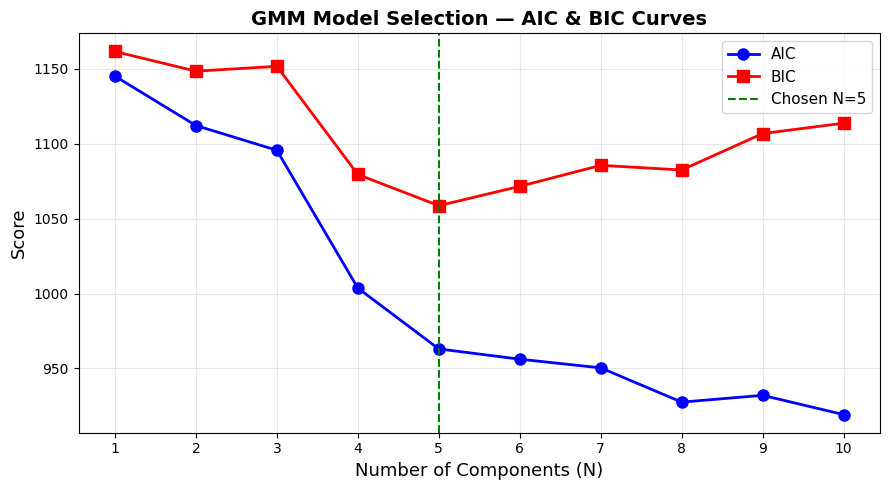

In [ ]:
# Plot AIC and BIC
plt.figure(figsize=(9, 5))
plt.plot(list(n_range), aic_scores, 'bo-', linewidth=2, markersize=8, label='AIC')
plt.plot(list(n_range), bic_scores, 'rs-', linewidth=2, markersize=8, label='BIC')
plt.axvline(x=5, color='green', linestyle='--', label='Chosen N=5')
plt.xlabel('Number of Components (N)', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.title('GMM Model Selection — AIC & BIC Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(list(n_range))
plt.tight_layout()
plt.savefig('gmm_aic_bic.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 3–6: Fit GMM, Predict Probabilities and Assign Labels

In [ ]:
# Step 3–6: Fit GMM with n_components=5 (EM algorithm runs internally)
n_components = 5
gmm = GaussianMixture(n_components=n_components, covariance_type='full',
                      random_state=42, n_init=5)
gmm.fit(X_scaled)

# Predict cluster probabilities (soft clustering)
proba_gmm = gmm.predict_proba(X_scaled)     # shape: (200, 5)

# Step 7: Assign labels based on highest probability (hard assignment)
labels_gmm = gmm.predict(X_scaled)
df['GMM_Cluster'] = labels_gmm

# Evaluation metrics
log_likelihood = gmm.score(X_scaled) * len(X_scaled)
aic_val  = gmm.aic(X_scaled)
bic_val  = gmm.bic(X_scaled)
sil_gmm  = silhouette_score(X_scaled, labels_gmm)

print("GMM Clustering Results (N = 5, full covariance)")
print("=" * 45)
print(f"  Log-Likelihood   : {log_likelihood:.4f}")
print(f"  AIC              : {aic_val:.4f}")
print(f"  BIC              : {bic_val:.4f}")
print(f"  Silhouette Score : {sil_gmm:.4f}")
print()
print("Cluster Distribution:")
for c in range(n_components):
    count = np.sum(labels_gmm == c)
    print(f"  Cluster {c}: {count} customers")

GMM Clustering Results (N = 5, full covariance)
  Log-Likelihood   : -452.5005
  AIC              : 963.0010
  BIC              : 1058.6523
  Silhouette Score : 0.5537

Cluster Distribution:
  Cluster 0: 84 customers
  Cluster 1: 39 customers
  Cluster 2: 21 customers
  Cluster 3: 33 customers
  Cluster 4: 23 customers


In [ ]:
# Show sample cluster probabilities for first 10 customers
print("Sample Cluster Membership Probabilities (first 10 customers):")
print(f"{'Cust':>5}", end="")
for c in range(n_components):
    print(f"  {'P(C'+str(c)+')':>8}", end="")
print(f"  {'Assigned':>9}")
print("-" * 65)
for i in range(10):
    print(f"{i+1:>5}", end="")
    for p in proba_gmm[i]:
        print(f"  {p:>8.4f}", end="")
    print(f"  {labels_gmm[i]:>9}")

Sample Cluster Membership Probabilities (first 10 customers):
 Cust     P(C0)     P(C1)     P(C2)     P(C3)     P(C4)   Assigned
-----------------------------------------------------------------
    1    0.0000    0.0000    0.0010    0.0000    0.9990          4
    2    0.0000    0.0002    0.9998    0.0000    0.0000          2
    3    0.0000    0.0000    0.0000    0.0002    0.9998          4
    4    0.0001    0.0002    0.9997    0.0000    0.0000          2
    5    0.0001    0.0000    0.0016    0.0000    0.9984          4
    6    0.0002    0.0002    0.9996    0.0000    0.0000          2
    7    0.0000    0.0000    0.0000    0.0003    0.9997          4
    8    0.0000    0.0003    0.9997    0.0000    0.0000          2
    9    0.0000    0.0000    0.0000    0.0004    0.9996          4
   10    0.0012    0.0002    0.9984    0.0000    0.0002          2


### Step 4: Visualize GMM Clusters

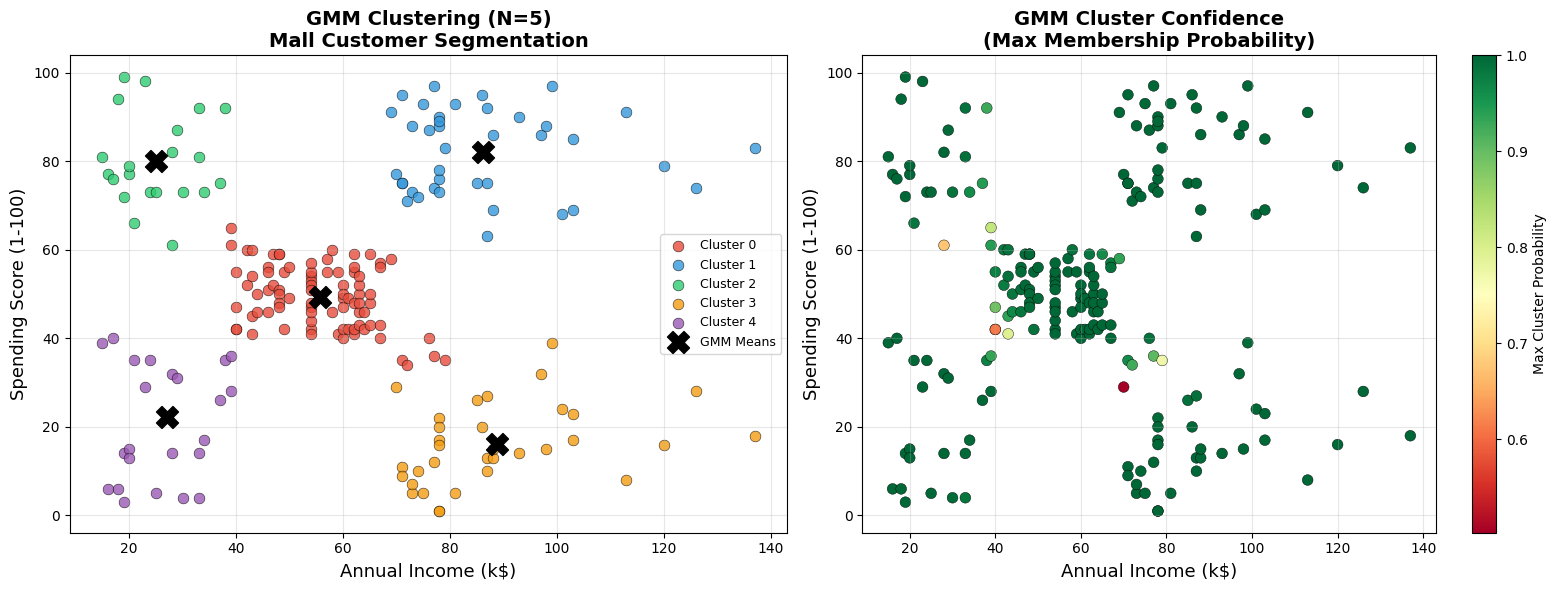

In [ ]:
# Visualize GMM clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_gmm = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# GMM cluster scatter
for c in range(n_components):
    mask = labels_gmm == c
    axes[0].scatter(X[mask, 0], X[mask, 1],
                    c=colors_gmm[c], label=f'Cluster {c}',
                    s=60, alpha=0.8, edgecolors='k', linewidths=0.4)

# GMM means in original scale
gmm_means_orig = scaler.inverse_transform(gmm.means_)
axes[0].scatter(gmm_means_orig[:, 0], gmm_means_orig[:, 1],
                c='black', marker='X', s=250, zorder=5, label='GMM Means')
axes[0].set_xlabel('Annual Income (k$)', fontsize=13)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=13)
axes[0].set_title('GMM Clustering (N=5)\nMall Customer Segmentation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Probability heatmap (max probability for each point = confidence)
max_proba = np.max(proba_gmm, axis=1)
sc = axes[1].scatter(X[:, 0], X[:, 1], c=max_proba,
                     cmap='RdYlGn', s=60, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=axes[1], label='Max Cluster Probability')
axes[1].set_xlabel('Annual Income (k$)', fontsize=13)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=13)
axes[1].set_title('GMM Cluster Confidence\n(Max Membership Probability)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gmm_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 5: GMM Contour Plot

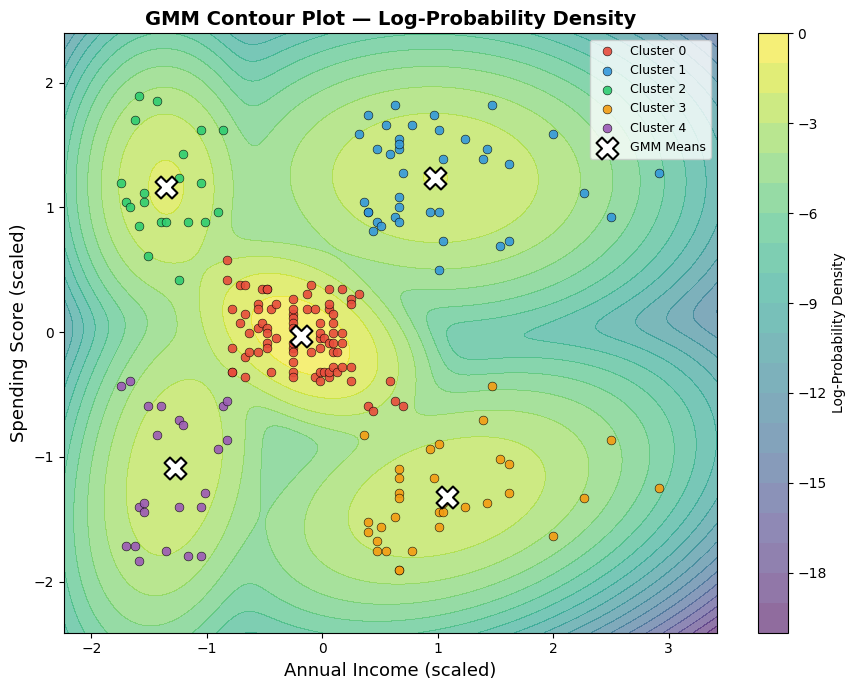

In [ ]:
# GMM Contour Plot (density estimation on scaled space)
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = gmm.score_samples(grid).reshape(xx.shape)

plt.figure(figsize=(9, 7))
contourf = plt.contourf(xx, yy, Z, levels=20, cmap='viridis', alpha=0.6)
plt.colorbar(contourf, label='Log-Probability Density')

for c in range(n_components):
    mask = labels_gmm == c
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                c=colors_gmm[c], s=40, edgecolors='k',
                linewidths=0.4, label=f'Cluster {c}', alpha=0.9)

plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1],
            c='white', marker='X', s=250, zorder=5,
            edgecolors='black', linewidths=1.5, label='GMM Means')

plt.xlabel('Annual Income (scaled)', fontsize=13)
plt.ylabel('Spending Score (scaled)', fontsize=13)
plt.title('GMM Contour Plot — Log-Probability Density', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('gmm_contour.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 8: Compare K-Means vs GMM

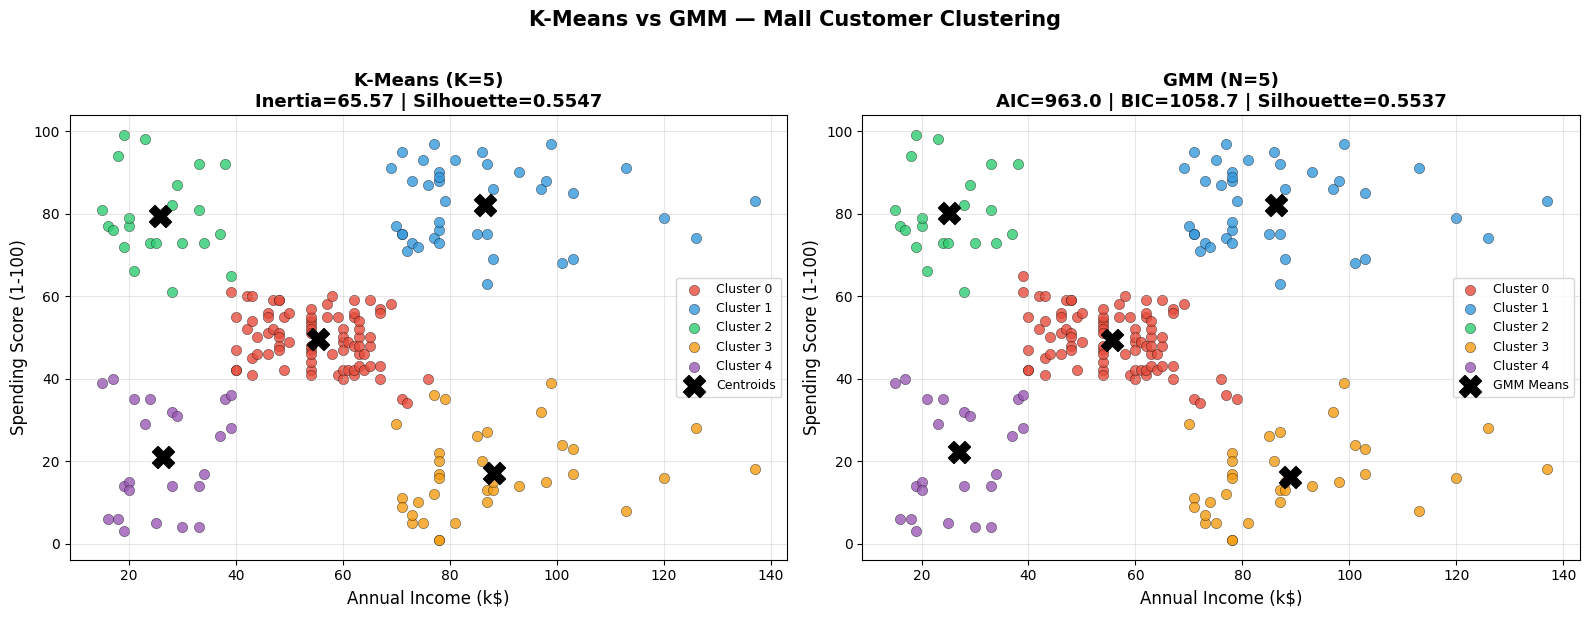


Comparison Summary:
--------------------------------------------------
Metric                       K-Means        GMM
--------------------------------------------------
Silhouette Score              0.5547     0.5537
Inertia / Log-Likelihood     65.5684  -452.5005
AIC                              N/A   963.0010
BIC                              N/A  1058.6523
Cluster Type                    Hard       Soft
Cluster Shape              Spherical Elliptical


In [ ]:
# Step 8: Side-by-side comparison of K-Means vs GMM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
for c in range(optimal_k):
    mask = cluster_labels_km == c
    axes[0].scatter(X[mask, 0], X[mask, 1],
                    c=colors[c], label=f'Cluster {c}',
                    s=55, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[0].scatter(centroids_original[:, 0], centroids_original[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].set_title(f'K-Means (K=5)\nInertia={inertia_final:.2f} | Silhouette={sil_score_km:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# GMM
for c in range(n_components):
    mask = labels_gmm == c
    axes[1].scatter(X[mask, 0], X[mask, 1],
                    c=colors_gmm[c], label=f'Cluster {c}',
                    s=55, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[1].scatter(gmm_means_orig[:, 0], gmm_means_orig[:, 1],
                c='black', marker='X', s=250, zorder=5, label='GMM Means')
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title(f'GMM (N=5)\nAIC={aic_val:.1f} | BIC={bic_val:.1f} | Silhouette={sil_gmm:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means vs GMM — Mall Customer Clustering', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_kmeans_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nComparison Summary:")
print("-" * 50)
print(f"{'Metric':<25} {'K-Means':>10} {'GMM':>10}")
print("-" * 50)
print(f"{'Silhouette Score':<25} {sil_score_km:>10.4f} {sil_gmm:>10.4f}")
print(f"{'Inertia / Log-Likelihood':<25} {inertia_final:>10.4f} {log_likelihood:>10.4f}")
print(f"{'AIC':<25} {'N/A':>10} {aic_val:>10.4f}")
print(f"{'BIC':<25} {'N/A':>10} {bic_val:>10.4f}")
print(f"{'Cluster Type':<25} {'Hard':>10} {'Soft':>10}")
print(f"{'Cluster Shape':<25} {'Spherical':>10} {'Elliptical':>10}")